# COVID‑19  
## JohnsHopkinsCovid19
Problem Statement

Task 1:- Prepare a complete data analysis report on the given data.

Task 2:- Fix a period for prediction of confirmed cases/deaths. Create a predictive model to forecast the Covid19 cases based on past cases for a specific country or region.

Task3:- Make suggestions to the government health department of the country/region for preparation based on your predictions.


## Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, accuracy_score

from statsmodels.tsa.arima.model import ARIMA


## Load Dataset

In [2]:
confirmed = pd.read_csv('time_series_covid19_confirmed_global.csv')
deaths = pd.read_csv('time_series_covid19_deaths_global.csv')
recovered = pd.read_csv('time_series_covid19_recovered_global.csv')

confirmed.head()


,Province/State,Country/Region,Lat,Long,1/22/20,1/23/20,1/24/20,1/25/20,1/26/20,1/27/20,...,9/12/20,9/13/20,9/14/20,9/15/20,9/16/20,9/17/20,9/18/20,9/19/20,9/20/20,9/21/20
0,NaN,Afghanistan,33.93911,67.709953,0,0,0,0,0,0,...,38641,38716,38772,38815,38855,38872,38883,38919,39044,39074
1,NaN,Albania,41.15330,20.168300,0,0,0,0,0,0,...,11185,11353,11520,11672,11816,11948,12073,12226,12385,12535
2,NaN,Algeria,28.03390,1.659600,0,0,0,0,0,0,...,48007,48254,48496,48734,48966,49194,49413,49623,49826,50023
3,NaN,Andorra,42.50630,1.521800,0,0,0,0,0,0,...,1344,1344,1438,1438,1483,1483,1564,1564,1564,1681
4,NaN,Angola,-11.20270,17.873900,0,0,0,0,0,0,...,3335,3388,3439,3569,3675,3789,3848,3901,3991,4117


## Data Cleaning

In [3]:
# Group data by country
confirmed_country = confirmed.groupby('Country/Region').sum(numeric_only=True)

# Remove latitude and longitude
confirmed_country = confirmed_country.drop(['Lat','Long'], axis=1)


## Select Country (India)

In [4]:
india = confirmed_country.loc['India']

# Convert to dataframe
india = india.reset_index()
india.columns = ['Date','Confirmed']

# Convert datatype
india['Confirmed'] = pd.to_numeric(india['Confirmed'], errors='coerce')

# Create day column for ML models
india['Day'] = np.arange(len(india))

india.head()


,Date,Confirmed,Day
0,1/22/20,0,0
1,1/23/20,0,1
2,1/24/20,0,2
3,1/25/20,0,3
4,1/26/20,0,4


## Visualization of Cases

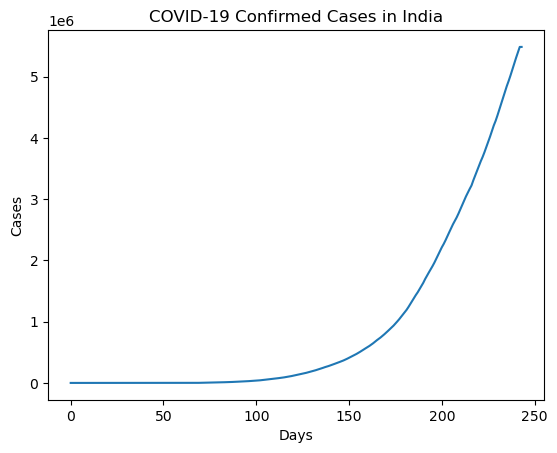

In [5]:
plt.figure()
plt.plot(india['Confirmed'])
plt.title("COVID‑19 Confirmed Cases in India")
plt.xlabel("Days")
plt.ylabel("Cases")
plt.show()


## Train Test Split  (Train = Learn ,Test = Check performance on unseen data)

In [6]:
X = india[['Day']]
y = india['Confirmed']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)


## Model 1 – Linear Regression

In [7]:
lr = LinearRegression()
lr.fit(X_train, y_train)

pred_lr = lr.predict(X_test)

print("Linear Regression MSE:", mean_squared_error(y_test, pred_lr))


Linear Regression MSE: 7479416028634.054


## Model 2 – Random Forest

In [8]:
rf = RandomForestRegressor(n_estimators=100)
rf.fit(X_train, y_train)

pred_rf = rf.predict(X_test)

print("Random Forest MSE:", mean_squared_error(y_test, pred_rf))


Random Forest MSE: 4204058561447.4766


## Model 3 – ARIMA Forecast

In [9]:
series = india['Confirmed'].astype(float)

model = ARIMA(series, order=(2,1,2))
model_fit = model.fit()

forecast = model_fit.forecast(steps=30)

print(forecast.head())


244    5.485541e+06
245    5.492901e+06
246    5.499765e+06
247    5.506559e+06
248    5.513267e+06
Name: predicted_mean, dtype: float64


# Suggestions for Government

1. Increase hospital beds and ICU capacity.
2. Continue vaccination programs.
3. Encourage mask usage in crowded places.
4. Improve testing and monitoring systems.


# Challenges Faced

1. Dataset had many date columns.
2. Data cleaning required for machine learning.
3. Time‑series data needed special models.

Techniques used:
- Pandas data cleaning
- Feature engineering
- Machine learning models
- Time series forecasting


# Conclusion

In this project we analyzed COVID‑19 data and predicted case trends.

Multiple models were used:
Linear Regression, Random Forest, and ARIMA forecast.

Random Forest and ARIMA provide better prediction for time‑series trends.
